# Learning to Control Incompressible Fluids with Differentiable Physics
This notebook will walk you through data generation, supervised network initialization and end-to-end training using our differentiable PDE solver, [Φ<sub>Flow</sub>](https://github.com/tum-pbs/PhiFlow).

The code below replicates the shape transitions (experiment 2 from the ICLR 2020 paper [Learning to Control PDEs with Differentiable Physics](https://ge.in.tum.de/publications/2020-iclr-holl/)). The original experiment was performed on an older version of the solver, the code for which can be found under `/legacy`. The experiment is described in detail in section D.2 of the [appendix](https://openreview.net/pdf?id=HyeSin4FPB).

If you havn't already, check out the notebook on controlling Burgers' Equation. It covers the basics in more detail.

In [1]:
import os
import sys
import warnings
import builtins

# 1. Suppress Python & TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Hides TF INFO and WARNING logs
warnings.filterwarnings("ignore")

# 2. Monkey-patch print to ignore lines with 'WARNING'
original_print = builtins.print
def filtered_print(*args, **kwargs):
    msg = " ".join(str(a) for a in args)
    if "WARNING" not in msg:
        original_print(*args, **kwargs)
builtins.print = filtered_print


import sys; sys.path.append('../PhiFlow'); sys.path.append('../src')
from shape_utils import load_shapes, distribute_random_shape, make_crescent, sample_shape_batch
from control.pde.incompressible_flow import IncompressibleFluidPDE
from control.control_training import ControlTraining
from control.sequences import StaggeredSequence, RefinedSequence
import matplotlib.pyplot as plt
from phi.flow import *

Could not load resample cuda libraries: CUDA binaries not found at /home/soeren/.pyenv/versions/3.6.15/envs/pde36/lib/python3.6/site-packages/phi/tf/cuda/build/resample.so. Run "python setup.py cuda" to compile them





## Data Generation

In [2]:
domain = Domain([64, 64])  # 1D Grid resolution and physical size
step_count = 16  # how many solver steps to perform
dt = 1.0  # Time increment per solver step
example_count = 8000
batch_size = 100
data_path = 'shape-transitions'
pretrain_data_path = 'moving-squares'
shape_library = load_shapes('shapes')

The following cell creates the dataset we want to train our model on.
Each example consists of a start and target (end) frame which are generated by placing a random shape somewhere within the domain.

In [3]:
for scene in Scene.list(data_path):
    scene.remove()

for _ in range(example_count // batch_size):
    scene = Scene.create(data_path, count=batch_size, copy_calling_script=False)
    print(scene)

    # o₁ = arbitrary shape
    start = sample_shape_batch(domain, batch_size, shape_library)

    # o* = crescent
    goal = sample_shape_batch(domain, batch_size, shape_library)

    for f in range(step_count):
        scene.write_sim_frame([start], ['density'], frame=f)

    scene.write_sim_frame([goal], ['density'], frame=step_count)


shape-transitions/sim_000000
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 2 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
shape-transitions/sim_000100
shape-transitions/sim_000200
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
shape-transitions/sim_000300
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
shape-transitions/sim_000400
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
shape-transitions/sim_000500
[sample_shape_batch] Attempt 1 failed with

Since this dataset does not contain any intermediate frames, it does not allow for supervised pretraining. This is because to pre-train a CFE, two consecutive frames are required and to pretrain an $OP_n$, three frames with distance $n/2$ are needed.

Instead, we create a second dataset which contains intermediate frames. This does not need to look like the actual dataset since it's only used for network initialization. Here, we linearly move a rectangle around the domain.

In [4]:
from phi.geom import AABox
import numpy as np

def make_shifted(shape, shift_xy):
    """ Shift a shape (B, H, W, 1) by (dx, dy) using np.roll """
    dy, dx = shift_xy
    return np.roll(np.roll(shape, dy, axis=1), dx, axis=2)

# Clear previous dataset
for scene in Scene.list(pretrain_data_path):
    scene.remove()

for scene_index in range(example_count // batch_size):
    scene = Scene.create(pretrain_data_path, count=batch_size, copy_calling_script=False)
    print(scene)

    # Generate shapes and movement targets
    start_shapes = sample_shape_batch(domain, batch_size, shape_library)
    end_shapes   = sample_shape_batch(domain, batch_size, shape_library)

    pos0 = np.random.randint(10, 56, (batch_size, 2))  # (y0, x0)
    pose = np.random.randint(10, 56, (batch_size, 2))  # (y1, x1)

    for frame in range(step_count + 1):
        t = frame / (step_count + 1)
        fade = np.clip((t - 0.5) * 2, 0, 1)  # from 0 to 1

        densities = []
        for b in range(batch_size):
            success = False
            attempts = 0
            while not success and attempts < 10:
                try:
                    # Interpolate position
                    pos = np.round(pos0[b] * (1 - t) + pose[b] * t).astype(int)
                    shift_from_center = pos - np.array(domain.resolution) // 2

                    start = sample_shape_batch(domain, 1, shape_library)[0]
                    end   = sample_shape_batch(domain, 1, shape_library)[0]

                    start_shifted = make_shifted(start[None], shift_from_center)
                    end_shifted   = make_shifted(end[None], shift_from_center)

                    blended = (1 - fade) * start_shifted + fade * end_shifted
                    densities.append(blended[0])  # shape: (H, W, 1)

                    success = True
                except IndexError:
                    attempts += 1
                    print(f"Retrying shape b={b} at frame={frame} (attempt {attempts})")

            if not success:
                raise RuntimeError(f"Failed to generate a valid shape for batch {b} after 10 attempts.")


        density_batch = np.stack(densities, axis=0)  # shape: (B, H, W, 1)
        scene.write_sim_frame([density_batch], ['density'], frame=frame)


moving-squares/sim_000000
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array from shape (0,0) into shape (64,64)
[sample_shape_batch] Attempt 1 failed with: could not broadcast input array fr

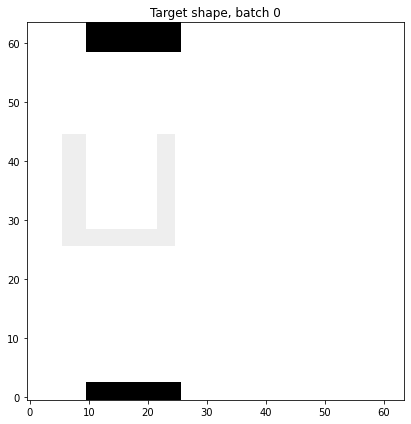

In [7]:
import pylab
from phi.flow import Scene

scene_ids = Scene.list(pretrain_data_path)
frame = step_count  # target frame

# Use the first scene directly
scene = scene_ids[5]
state = scene.read_array('density', frame=frame)  # shape: [batch, x, y, 1]

batch_count = state.shape[0]
batches = list(range(min(3, batch_count)))  # show up to 3 batches safely

pylab.subplots(len(batches), 1, figsize=(6, 6))
for i, batch in enumerate(batches):
    pylab.subplot(len(batches), 1, i + 1)
    pylab.imshow(state[batch, ..., 0], origin='lower', cmap='Greys')
    pylab.title(f"Target shape, batch {batch}")
pylab.tight_layout()
pylab.show()


# Supervised Initialization

In [8]:
test_range = range(100)
val_range = range(100, 500)
train_range = range(500, 7500)

The following cell trains the $OP_2$, $OP_4$, $OP_8$, $OP_{16}$ networks from scratch. You can skip it and load the checkpoints by running the cell after.

In [ ]:
supervised_checkpoints = {}

for n in [2, 4, 8, 16]:
    app = ControlTraining(n, IncompressibleFluidPDE(domain, dt),
                          datapath=pretrain_data_path, val_range=val_range, train_range=train_range, trace_to_channel=lambda _: 'density',
                          obs_loss_frames=[n//2], trainable_networks=['OP%d' % n],
                          sequence_class=None).prepare()
    for i in range(3000):
        app.progress()  # Run Optimization for one batch
    supervised_checkpoints['OP%d' % n] = app.save_model()

In [10]:
supervised_checkpoints

{'OP2': '/home/soeren/phi/model/control-training/sim_000106/checkpoint_00001000',
 'OP4': '/home/soeren/phi/model/control-training/sim_000107/checkpoint_00001000',
 'OP8': '/home/soeren/phi/model/control-training/sim_000108/checkpoint_00001000',
 'OP16': '/home/soeren/phi/model/control-training/sim_000109/checkpoint_00001000'}

In [ ]:
# supervised_checkpoints = {'OP%d' % n: '../networks/shapes/supervised/OP%d_1000' % n for n in [2, 4, 8, 16]}

# CFE Pretraining with Differentiable Physics

To pretrain the CFE, we set up a simulation with a single step of the differentiable solver.

The following cell trains the CFE network from scratch. You can skip it an load the checkpoint by running the cell after.

In [ ]:
app = ControlTraining(1, IncompressibleFluidPDE(domain, dt),
                      datapath=pretrain_data_path, val_range=val_range, train_range=train_range, trace_to_channel=lambda _: 'density',
                      obs_loss_frames=[1], trainable_networks=['CFE']).prepare()
for i in range(3000):
    app.progress()  # Run Optimization for one batch
supervised_checkpoints['CFE'] = app.save_model()

In [ ]:
# supervised_checkpoints['CFE'] = '../networks/shapes/CFE/CFE_2000'

# End-to-end Training with Differentiable Physics

Now, we jointly train $CFE$ and all $OP_n$ networks. The following cell builds the computational graph with `step_count` solver steps without initializing the network weights.

In [ ]:
staggered_app = ControlTraining(step_count, IncompressibleFluidPDE(domain, dt),
                                datapath=data_path, val_range=val_range, train_range=train_range, trace_to_channel=lambda _: 'density',
                                obs_loss_frames=[step_count], trainable_networks=['CFE', 'OP2', 'OP4', 'OP8', 'OP16'],
                                sequence_class=StaggeredSequence, learning_rate=5e-4).prepare()

The next cell initializes the networks using the supervised checkpoints and then trains all networks jointly. You can skip it and load the checkpoint by running the cell after.

In [14]:
staggered_app.load_checkpoints(supervised_checkpoints)
for i in range(5000):
    staggered_app.progress()  # Run staggered Optimization for one batch
staggered_checkpoint = staggered_app.save_model()
print("Checkpoint saved to:", staggered_checkpoint)

Loading CFE from /home/soeren/phi/model/control-training/sim_000110/checkpoint_00001000... (INFO), 2025-07-21 05:57:23,346n

Instructions for updating:
Use standard file APIs to check for files with this prefix.


Instructions for updating:
Use standard file APIs to check for files with this prefix.


INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000110/checkpoint_00001000/model.ckpt


INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000110/checkpoint_00001000/model.ckpt


Loading OP2 from /home/soeren/phi/model/control-training/sim_000106/checkpoint_00001000... (INFO), 2025-07-21 05:57:24,947n

INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000106/checkpoint_00001000/model.ckpt


...

Loading OP8 from /home/soeren/phi/model/control-training/sim_000108/checkpoint_00001000... (INFO), 2025-07-21 05:57:28,169n

INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000108/checkpoint_00001000/model.ckpt


INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000108/checkpoint_00001000/model.ckpt


Loading OP16 from /home/soeren/phi/model/control-training/sim_000109/checkpoint_00001000... (INFO), 2025-07-21 05:57:29,799n

INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000109/checkpoint_00001000/model.ckpt


INFO:tensorflow:Restoring parameters from /home/soeren/phi/model/control-training/sim_000109/checkpoint_00001000/model.ckpt


Optimization (000000): Learning_Rate: 0.0005, GT_obs_16: 923977.75, Loss_reg_unscaled: 10497237.0, Loss_reg_scale: 1.0, Loss: 1847955.5 (INFO), 2025-07-21 05:57:54,885n

Validation (000000): Learning_Rate: 0.0005, GT_obs_16: 1681709.1, Loss_reg_unscaled: 13626776.0, Loss_reg_scale: 1.0, Loss: 3363418.2 (INFO), 2025-07-21 05:57:57,673n

Optimization (000050): Learning_Rate: 0.0005, GT_obs_16: 918407.25, Loss_reg_unscaled: 5399584.5, Loss_reg_scale: 1.0, Loss: 1836814.5 (INFO), 2025-07-21 05:58:52,254n

Validation (000050): Learning_Rate: 0.0005, GT_obs_16: 1680007.9, Loss_reg_unscaled: 9806515.0, Loss_reg_scale: 1.0, Loss: 3360015.8 (INFO), 2025-07-21 05:58:54,415n

Optimization (000100): Learning_Rate: 0.0005, GT_obs_16: 892914.9, Loss_reg_unscaled: 2790049.0, Loss_reg_scale: 1.0, Loss: 1785829.8 (INFO), 2025-07-21 05:59:48,317n

Validation (000100): Learning_Rate: 0.0005, GT_obs_16: 1657587.5, Loss_reg_unscaled: 5133088.5, Loss_reg_scale: 1.0, Loss: 3315175.0 (INFO), 2025-07-21 05:59:

In [ ]:
# staggered_checkpoint = {net: '../networks/shapes/staggered/all_53750' for net in ['CFE', 'OP2', 'OP4', 'OP8', 'OP16']}
# staggered_app.load_checkpoints(staggered_checkpoint)

Now that the network is trained, we can infer some trajectories from the test set.
This corresponds to Fig 5b and 18b from the [paper](https://openreview.net/pdf?id=HyeSin4FPB).

<class 'phi.data.fluidformat.Scene'>


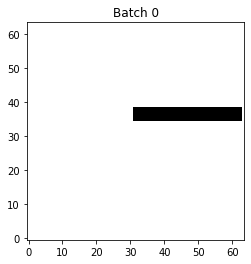

In [8]:
from phi.flow import Scene
import pylab
from pprint import pprint

scene_ids = Scene.list(data_path)
scene = scene_ids[0]  # Choose any test scene
pprint(scene.__class__)
state = scene.read_array('density', frame=step_count)  # Already a NumPy array

for i in range(state.shape[0]):
    pylab.imshow(state[i, ..., 0], origin='lower', cmap='Greys')
    pylab.title(f"Batch {i}")
    pylab.show()


In [15]:
states = staggered_app.infer_all_frames(test_range)

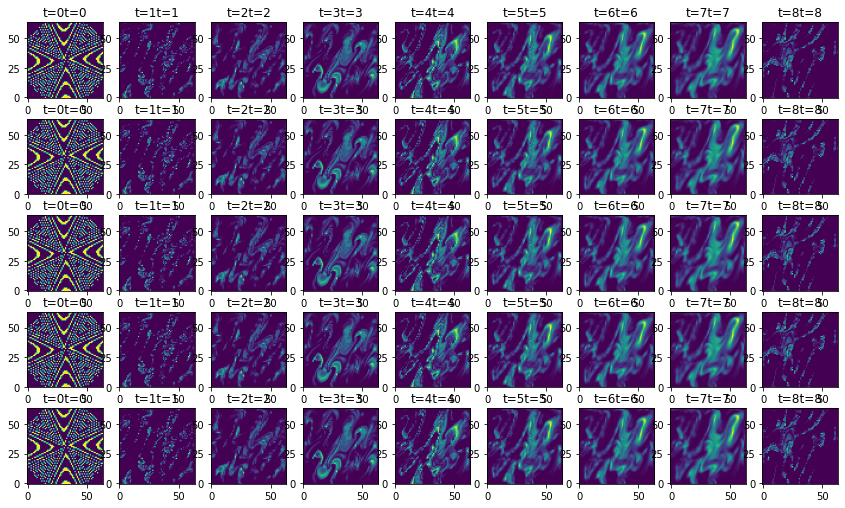

In [18]:
import pylab
batches = [0, 1, 2]
pylab.subplots(len(batches), 9, sharey='row', sharex='col', figsize=(12, 7))
pylab.tight_layout(w_pad=0)
for i, batch in enumerate(batches):
    for t in range(9):
        pylab.subplot(len(batches), 9, t + 1 + i * 9)
        pylab.title('t=%d' % t * 2)
        pylab.imshow(states[t * 2].density.data[batch, ..., 0], origin='lower')
pylab.savefig('shape-transitions.png')

Using the same procedure as with the Burgers example, we could use a `RefinedSequence` and train with the prediction refinement scheme. The results are already looking rather nice, so we'll leave it up to the reader ;-)